In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
import gc

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [3]:
G_hi = 20.5
G_lo = 20.0

In [4]:
nthreads = 18

In [5]:
# cosmology 1
h=0.6844
Omega_m = 0.302

# cosmology 2
Omega_m_quaia = 0.343
h_quaia = 0.674

In [6]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [7]:
H0 = h*100 * u.km/u.s/u.Mpc
rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))

H0_quaia = h_quaia*100 * u.km/u.s/u.Mpc
rbins_Mpc_quaia = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_quaia))

In [8]:
color1 = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, 2))[::-1]
color2 = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, 2))[::-1]

In [9]:
color3 = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, 2))[::-1]

In [10]:
# Create the bins array
rpmin = 0.15 # 0.5 # 0.1 # start higher
rpmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rpbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

In [11]:
pimax = 80 # 40 # 5000.0 # 40.0

In [12]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

In [13]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [14]:
Omega_c = 0.2513
Omega_b = 0.048
Omega_m_planck = Omega_c+Omega_b
cosmo = ccl.Cosmology(Omega_c=Omega_m*Omega_c/Omega_m_planck, Omega_b=Omega_m*Omega_b/Omega_m_planck,
                          h=h, n_s=0.95, sigma8=0.8)
cosmo_quaia = ccl.Cosmology(Omega_c=Omega_m_quaia*Omega_c/Omega_m_planck, Omega_b=Omega_m_quaia*Omega_b/Omega_m_planck,
                          h=h_quaia, n_s=0.95, sigma8=0.766)

In [15]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [16]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
grey = plt.get_cmap('Greys')((0.333+0.999)/2)
colors = [orange, green]

In [17]:
labels = ['Planck18', 'Quaia23']

In [18]:
h = 0.6774
Delta = 200
delta_c = 1.686

In [19]:
cosmo_default = ccl.Cosmology(Omega_b=0.0486, Omega_c=0.2589, h=h, n_s=0.9667, sigma8=0.8159)
hmf = ccl.halos.MassFuncTinker10()

## Define functions

In [20]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [21]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [22]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_default):
    
    sigma = cosmo.sigmaM(M/cosmo['h'], a = a)
   
    return delta_c/sigma

In [23]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_default, hmf = hmf):

    nm = hmf(cosmo, quaia.recenter(bins)/cosmo['h'], a)/cosmo['h']**3
    n_g = nm/(quaia.recenter(bins)*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_default, mod = False):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo)
    n_g = np.trapz(n_g, quaia.recenter(bins))
    dm = np.diff(bins) 
    dn_dm = nm/(quaia.recenter(bins)*np.log(10))

    b1_E_tinker = b1_E_func(nu(quaia.recenter(bins), a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins), n_g

In [24]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins):
    return 1/n_g*np.trapz(integrand*b, quaia.recenter(bins))

In [25]:
def cf_2h(bins, n_m, a, cosmo, cf_matter):
    
    b_q, n_g = bias(bins, n_m, a, cosmo)
    return b_q**2*cf_matter, b_q

In [26]:
def M(bins, n_m, a = 1, cosmo = cosmo_default, mod = False):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo)
    n_g = np.trapz(n_g, quaia.recenter(bins))
    dm = np.diff(bins) 
    dn_dm = nm/(quaia.recenter(bins)*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, quaia.recenter(bins), bins), n_g

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### Vary parameters

In [27]:
bins = np.logspace(9, 16.9, 50)
M_min = 12.8
# M_min_sun = 12.8*u.solMass
# H0 = h_array[i]*100 * u.km/u.s/u.Mpc
# M_min = (M_min_sun*cu.littleh).to(u.solMass, cu.with_H0(H0))/cu.littleh

In [28]:
# fduty = 4.5/100
# n_m=np.zeros(np.shape(quaia.recenter(bins)))
# n_m[quaia.recenter(bins)>=10**M_min]=fduty

fduty = [0.018, 0.022, 0.056, 0.071]
n_m_array = []
for i in z_array:
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min]=fduty[i]
    n_m_array.append(n_m)

<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:2: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_20814/1156436585.py:2: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])
/tmp/ipykernel_20814/1156436585.py:4: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


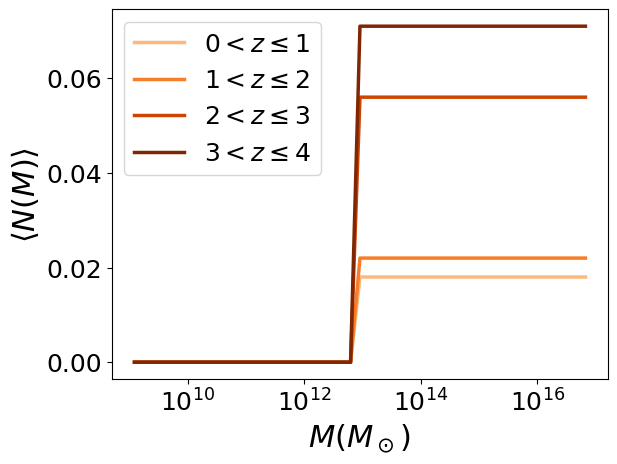

In [29]:
for i in z_array:
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1), color = cmap_qq[i])
plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [30]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']

cf_zbin_percentile, cf_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
yerr_cf, b_cf = {label: [] for label in labels}, {label: [] for label in labels}
a_zbin, b_cf_q = {label: [] for label in labels}, {label: [] for label in labels}
i = 1
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    cf, qq, qr = quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
               rbins = rbins, Om0 = Omega_m_array[i], h = h_array[i], error = True)
    cf_zbin_percentile[labels[i]].append(cf)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin[labels[i]].append(a)

    # matter correlation function
    H0 = h_array[i]*100 * u.km/u.s/u.Mpc
    rbins_Mpc = (quaia.recenter(rbins)*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
    cf_matter = ccl.correlations.correlation_3d(cosmos[i], r=rbins_Mpc, a=a)
    cf_matter_zbin_percentile[labels[i]].append(cf_matter)

    # effective bias 
    b = np.sqrt(cf/cf_matter)
    b_cf[labels[i]].append(b)

    # yerr
    yerr=(1+cf)/np.sqrt(qq)
    yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
    yerr_cf[labels[i]].append(yerr)

    # qso bias
    b_cf_q[labels[i]].append(b_qso(cf, cf_matter, ccl.growth_rate(cosmos[i], a)))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_20814/270260526.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_20814/270260526.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_20814/270260526.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_20814/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_20814/270260526.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_20814/270260526.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_20814/270260526.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_20814/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_20814/270260526.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_20814/270260526.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_20814/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_20814/270260526.py:34: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(cf/cf_matter)
/tmp/ipykernel_20814/270260526.py:38: RuntimeWarning: divide by zero encountered in divide
  yerr=(1+cf)/np.sqrt(qq)
/tmp/ipykernel_20814/270260526.py:39: RuntimeWarning: divide by zero encountered in divide
  yerr[cf<0]=np.sqrt((1+b**2*cf_matter)/qr)[cf<0] #https://arxiv.org/abs/1603.04849
/tmp/ipykernel_20814/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


## Measure $\xi(s)$ and calculate the two-halo term: $\xi_{2 h}(r) \approx\left[n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle b_h(M)\right]^2 \xi_m(r)$
###  Implement Poisson error bars: $\Delta \xi(s)=\begin{cases}\frac{1+\xi(s)}{\sqrt{DD(s)}} & \xi(s)\geq 0 \\ \sqrt{\frac{1+\xi(s)_\mathrm{model}}{D R}} & \xi(s)<0\end{cases}$ 

In [31]:
b_eff_cf20 = np.load('../results/b_eff_cf20.npy')
b_eff_wp20 = np.load('../results/b_eff_wp20.npy')

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20814/3495410985.py:21: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])


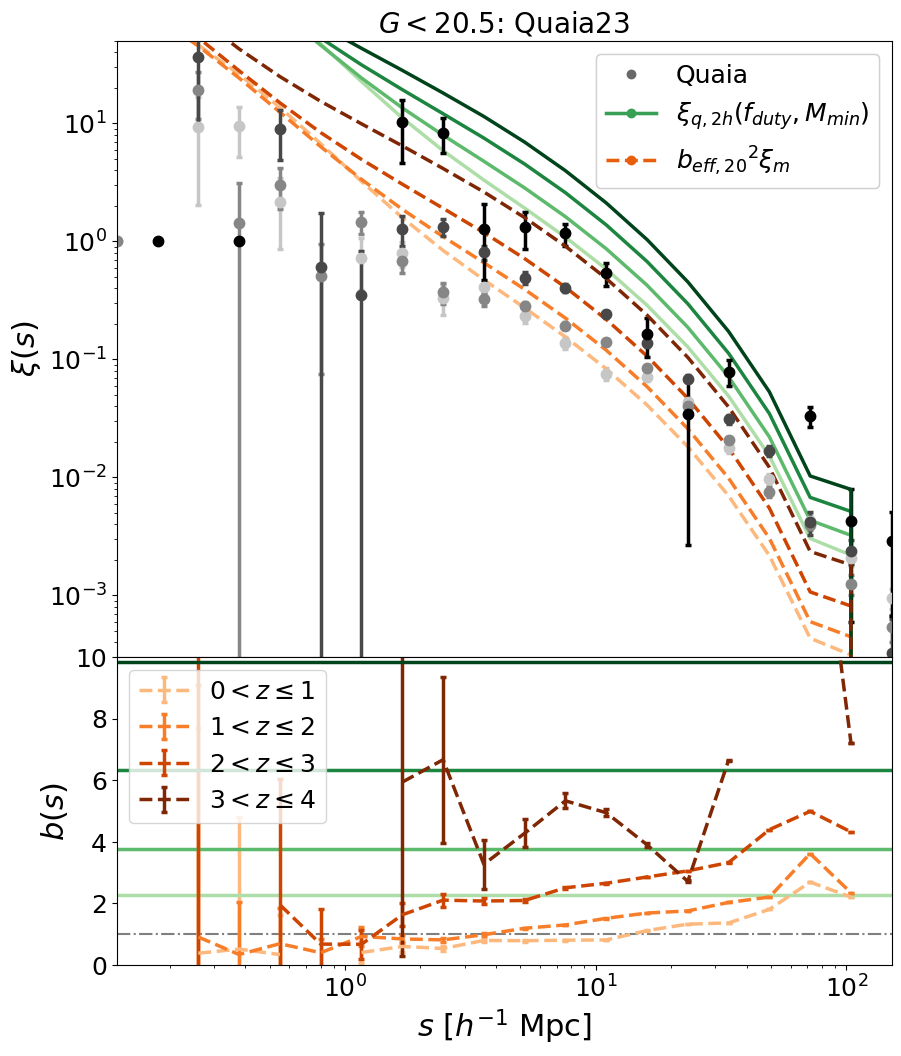

In [32]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', r'$\xi_{2h}$']
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

i = 1
for j in z_array:

    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_b[j], 
                 yerr = yerr_cf[labels[i]][j], linestyle = 'none', markeredgewidth = 2.5, capsize = 2.5) #  markerfacecolor = 'white'
    cf_2h_zbin, b_q = cf_2h(bins, n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j])
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}',
             color = cmap_mm[j], linestyle = '-')
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, linestyle = '--',
             label = r'$b_{20}$ model', color = cmap_qq[j])

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, capsize = 2.5, markeredgewidth = 2.5, linestyle = '--',
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])
    
ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax1.set_xticklabels([])
ax1.set_ylim(3e-4, 5e1)

custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
ax1.add_artist(second_legend)

ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
ax2.axhline(1, linestyle = '-.', color = 'black', zorder = 0, alpha = 0.5)
ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
ax2.set_ylim(0, 10)
ax2.legend()

ax1.set_ylabel(r'$\xi(s)$')
ax2.set_ylabel(r'$b(s)$')

if scale == 'log':
    ax1.set_xscale('log')
    ax2.set_xscale('log')

plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20814/3783650150.py:19: SyntaxWarning: invalid escape sequence '\l'
  label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
/tmp/ipykernel_20814/3783650150.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


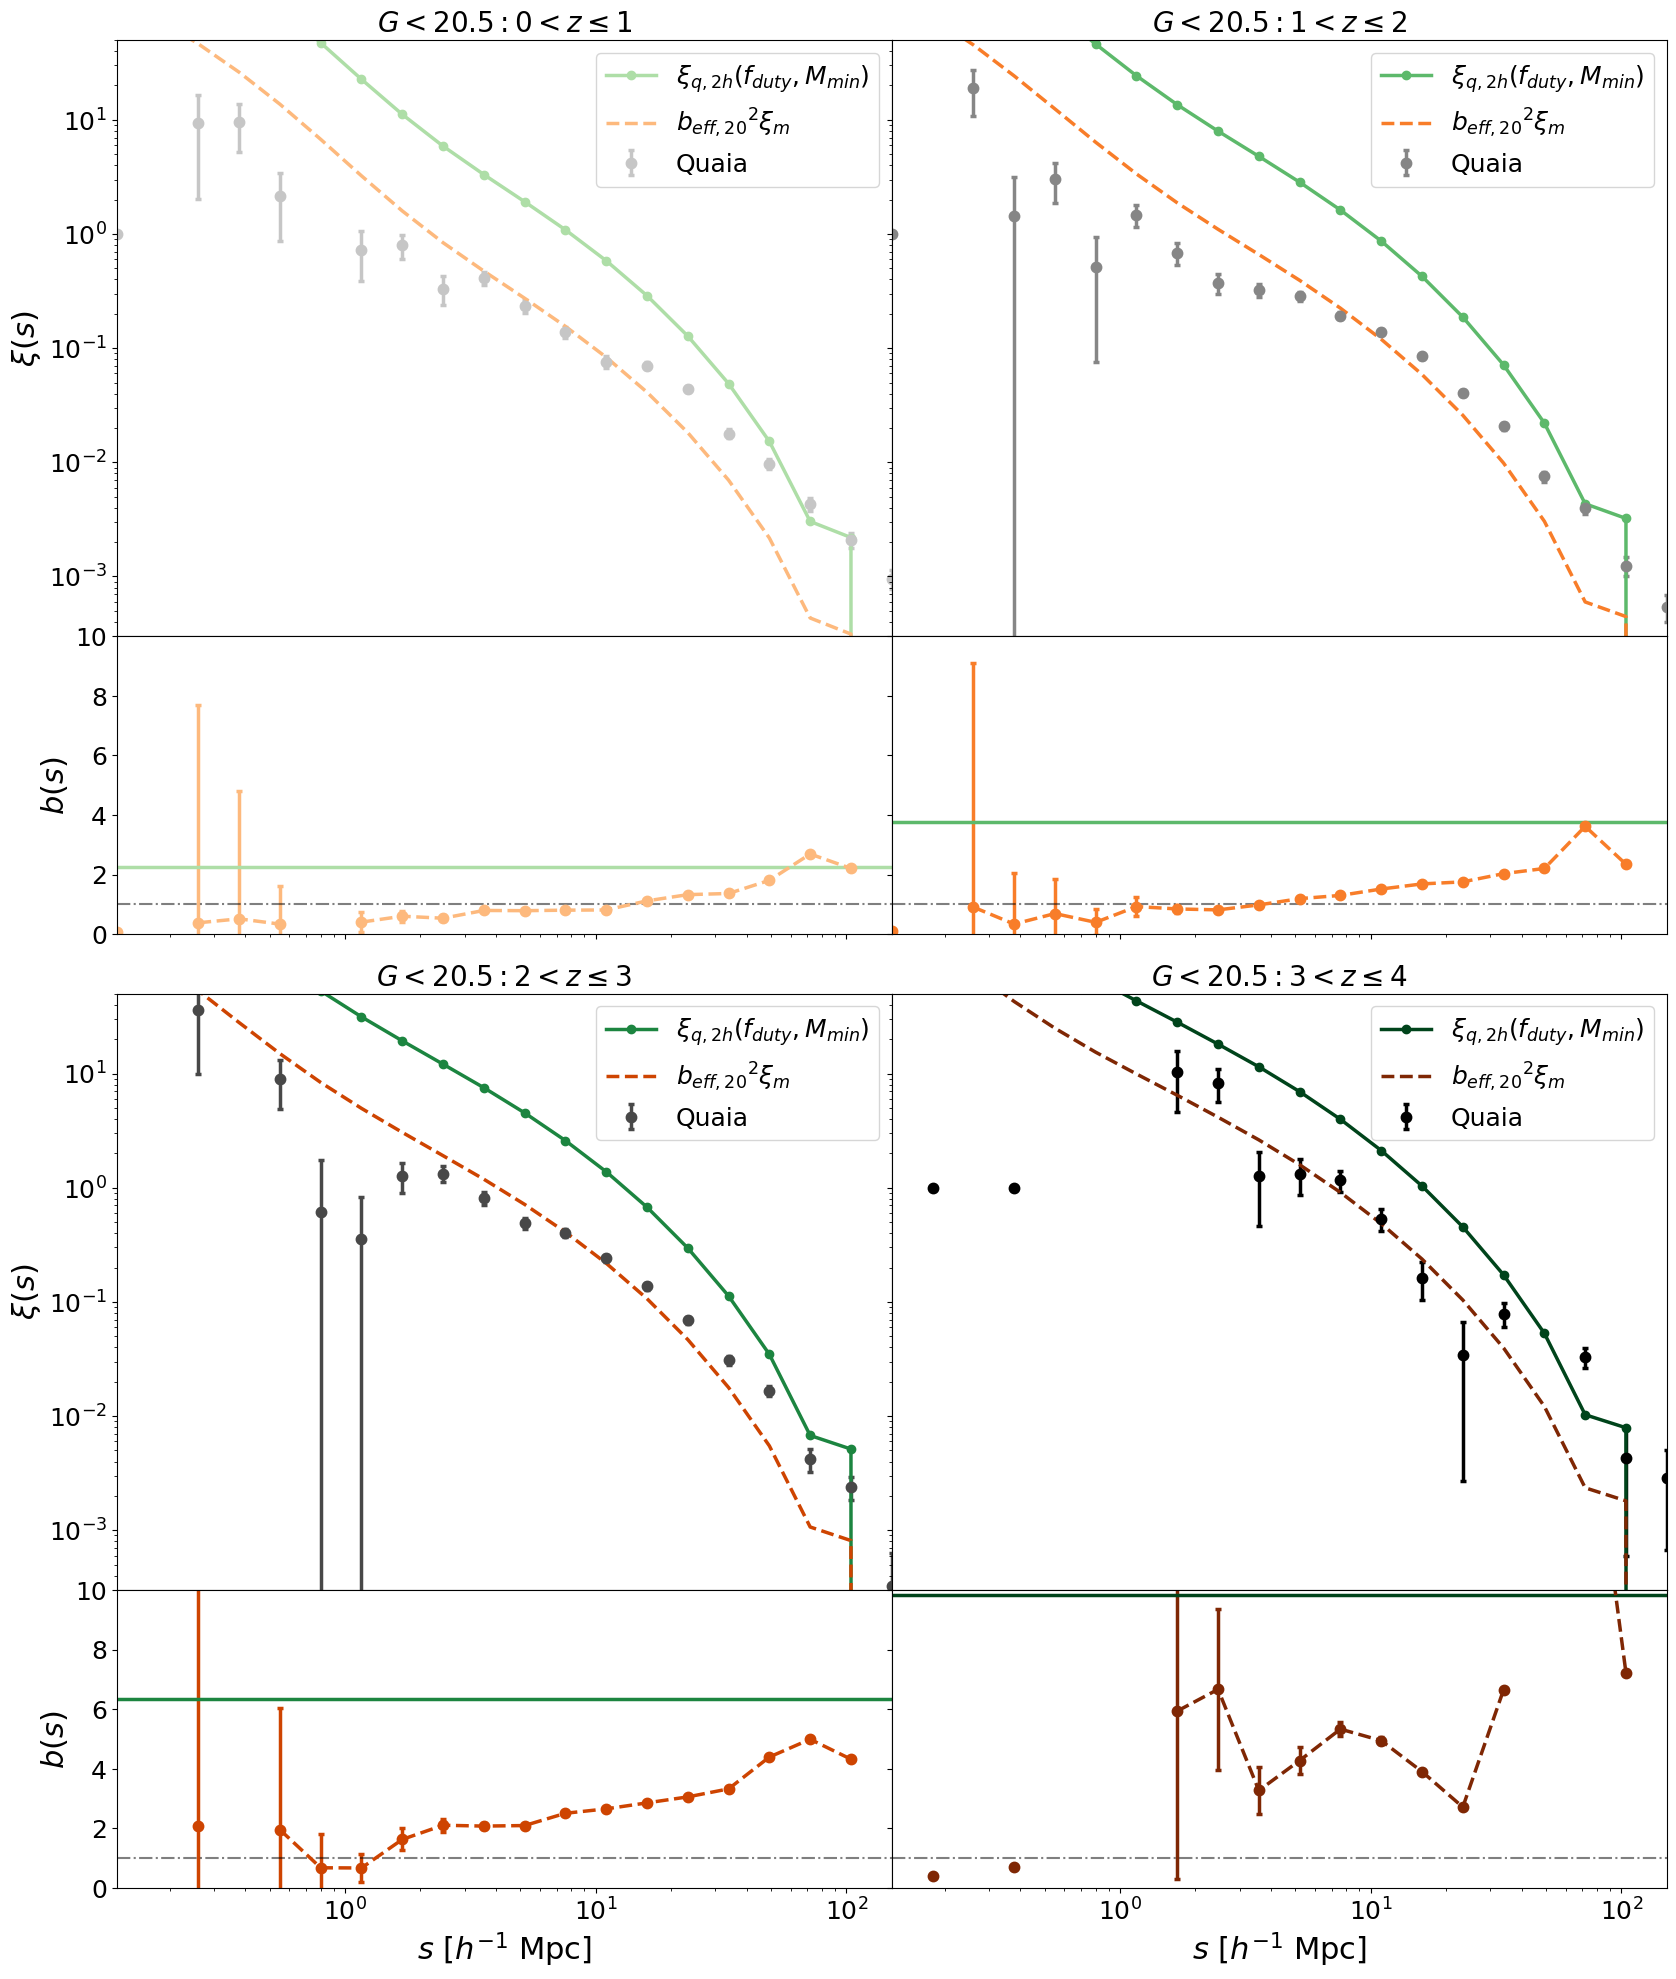

In [33]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
            
    ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = cmap_b[j],
                yerr = yerr_cf[labels[i]][j], markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    cf_2h_zbin, b_q = cf_2h(bins, n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j])
    ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'$\xi_{q,2h}(f_{duty}, M_{min})$',
             color = cmaps[i][j])
    ax1.plot(quaia.recenter(rbins), b_eff_cf20[j]**2*cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = cmap_qq[j], linestyle = '--')

    ax2.errorbar(quaia.recenter(rbins), b_cf[labels[i]][j], linewidth = 2.5, marker = 'o', linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
    ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

### Try a galactic latitude mask

<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20814/2558308004.py:21: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), capsize = 2.5,
/tmp/ipykernel_20814/2558308004.py:42: SyntaxWarning: invalid escape sequence '\l'
  patch = [mpatches.Patch(color=cmaps[i][k], label = '${:.0f}<z \leq{:.0f}$'.format(k, k+1)) for k in z_array]


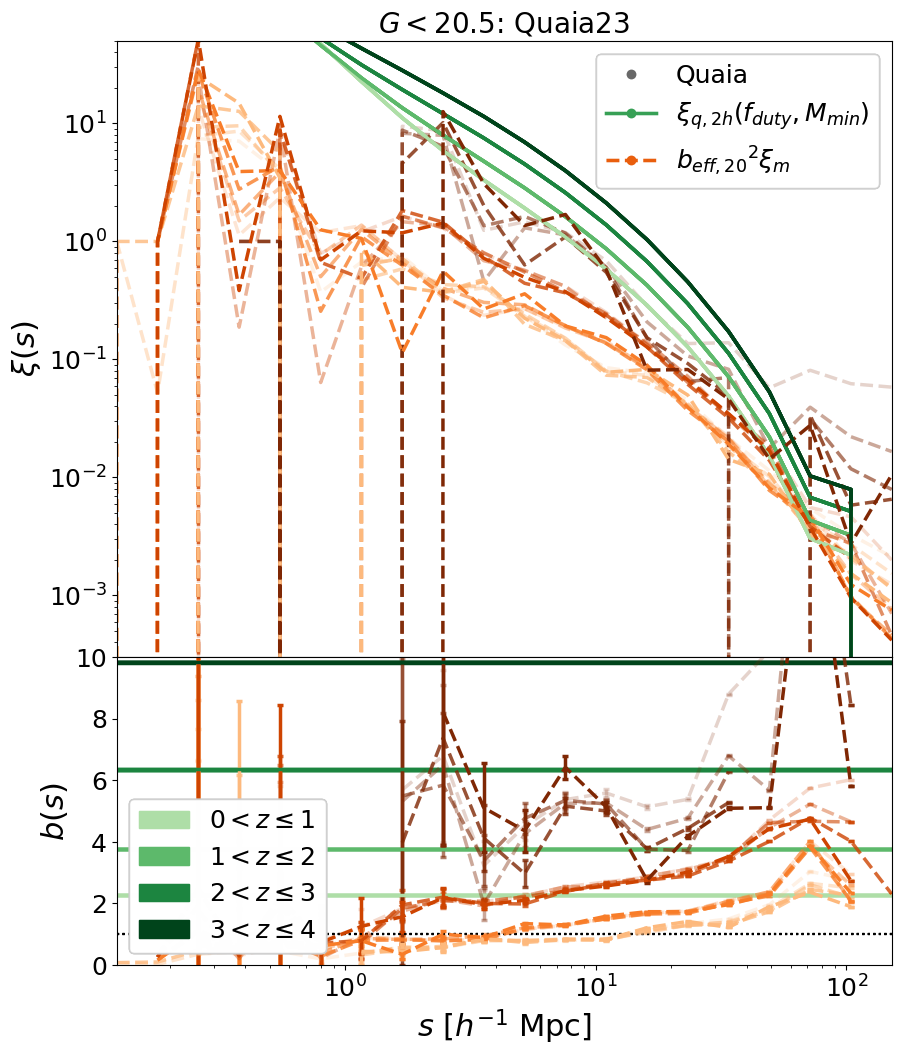

In [34]:
fig = plt.figure(figsize = (10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.5], hspace = 0, wspace = 0)
        
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

for b in [10, 20, 30, 40, 50]:

    for j in z_array:

        cf = np.load('../results/cf_{}_b{}_z{}.npy'.format(labels[i],b,j))
        cf_matter = np.load('../results/cf_matter_{}_b{}_z{}.npy'.format(labels[i],b,j))
        a = np.load('../results/a_{}_b{}_z{}.npy'.format(labels[i],b,j))
        yerr = np.load('../results/yerr_{}_b{}_z{}.npy'.format(labels[i],b,j))
        cf_2h_zbin, b_q = cf_2h(bins, n_m_array[j], float(a), cosmos[i], cf_matter)
        ax1.plot(quaia.recenter(rbins), cf, linewidth = 2.5, linestyle = '--', alpha = b/50,
                 label = r'$b_{20}$ model', color = cmap_qq[j])
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, label = r'\xi_2h}', color = cmap_mm[j], linestyle = '-')
        
        b_eff = np.load('../results/b_eff_{}_b{}_z{}.npy'.format(labels[i],b,j))
        ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), capsize = 2.5, 
                     markeredgewidth = 2.5, color = cmap_qq[j], yerr = yerr, alpha = b/50, linestyle = '--')
        ax2.axhline(b_q, linewidth = 2.5, color = cmaps[i][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)

    custom_lines = [Line2D([0], [0], color = grey, marker = 'o', linestyle = 'none', linewidth = 2.5),
                    Line2D([0], [0], color = green, marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = orange, marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, ['Quaia', r'$\xi_{q,2h}(f_{duty}, M_{min})$', r'${b_{eff, 20}}^2\xi_m$'], loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = ':', color = 'black')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    
    patch = [mpatches.Patch(color=cmaps[i][k], label = '${:.0f}<z \leq{:.0f}$'.format(k, k+1)) for k in z_array]
    first_legend = ax2.legend(handles=patch, loc = 'lower left')
    ax2.add_artist(first_legend)

    ax1.set_ylabel(r'$\xi(s)$')
    ax2.set_ylabel(r'$b(s)$')

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_20814/2943062229.py:23: SyntaxWarning: invalid escape sequence '\l'
  ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1),
/tmp/ipykernel_20814/2943062229.py:28: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


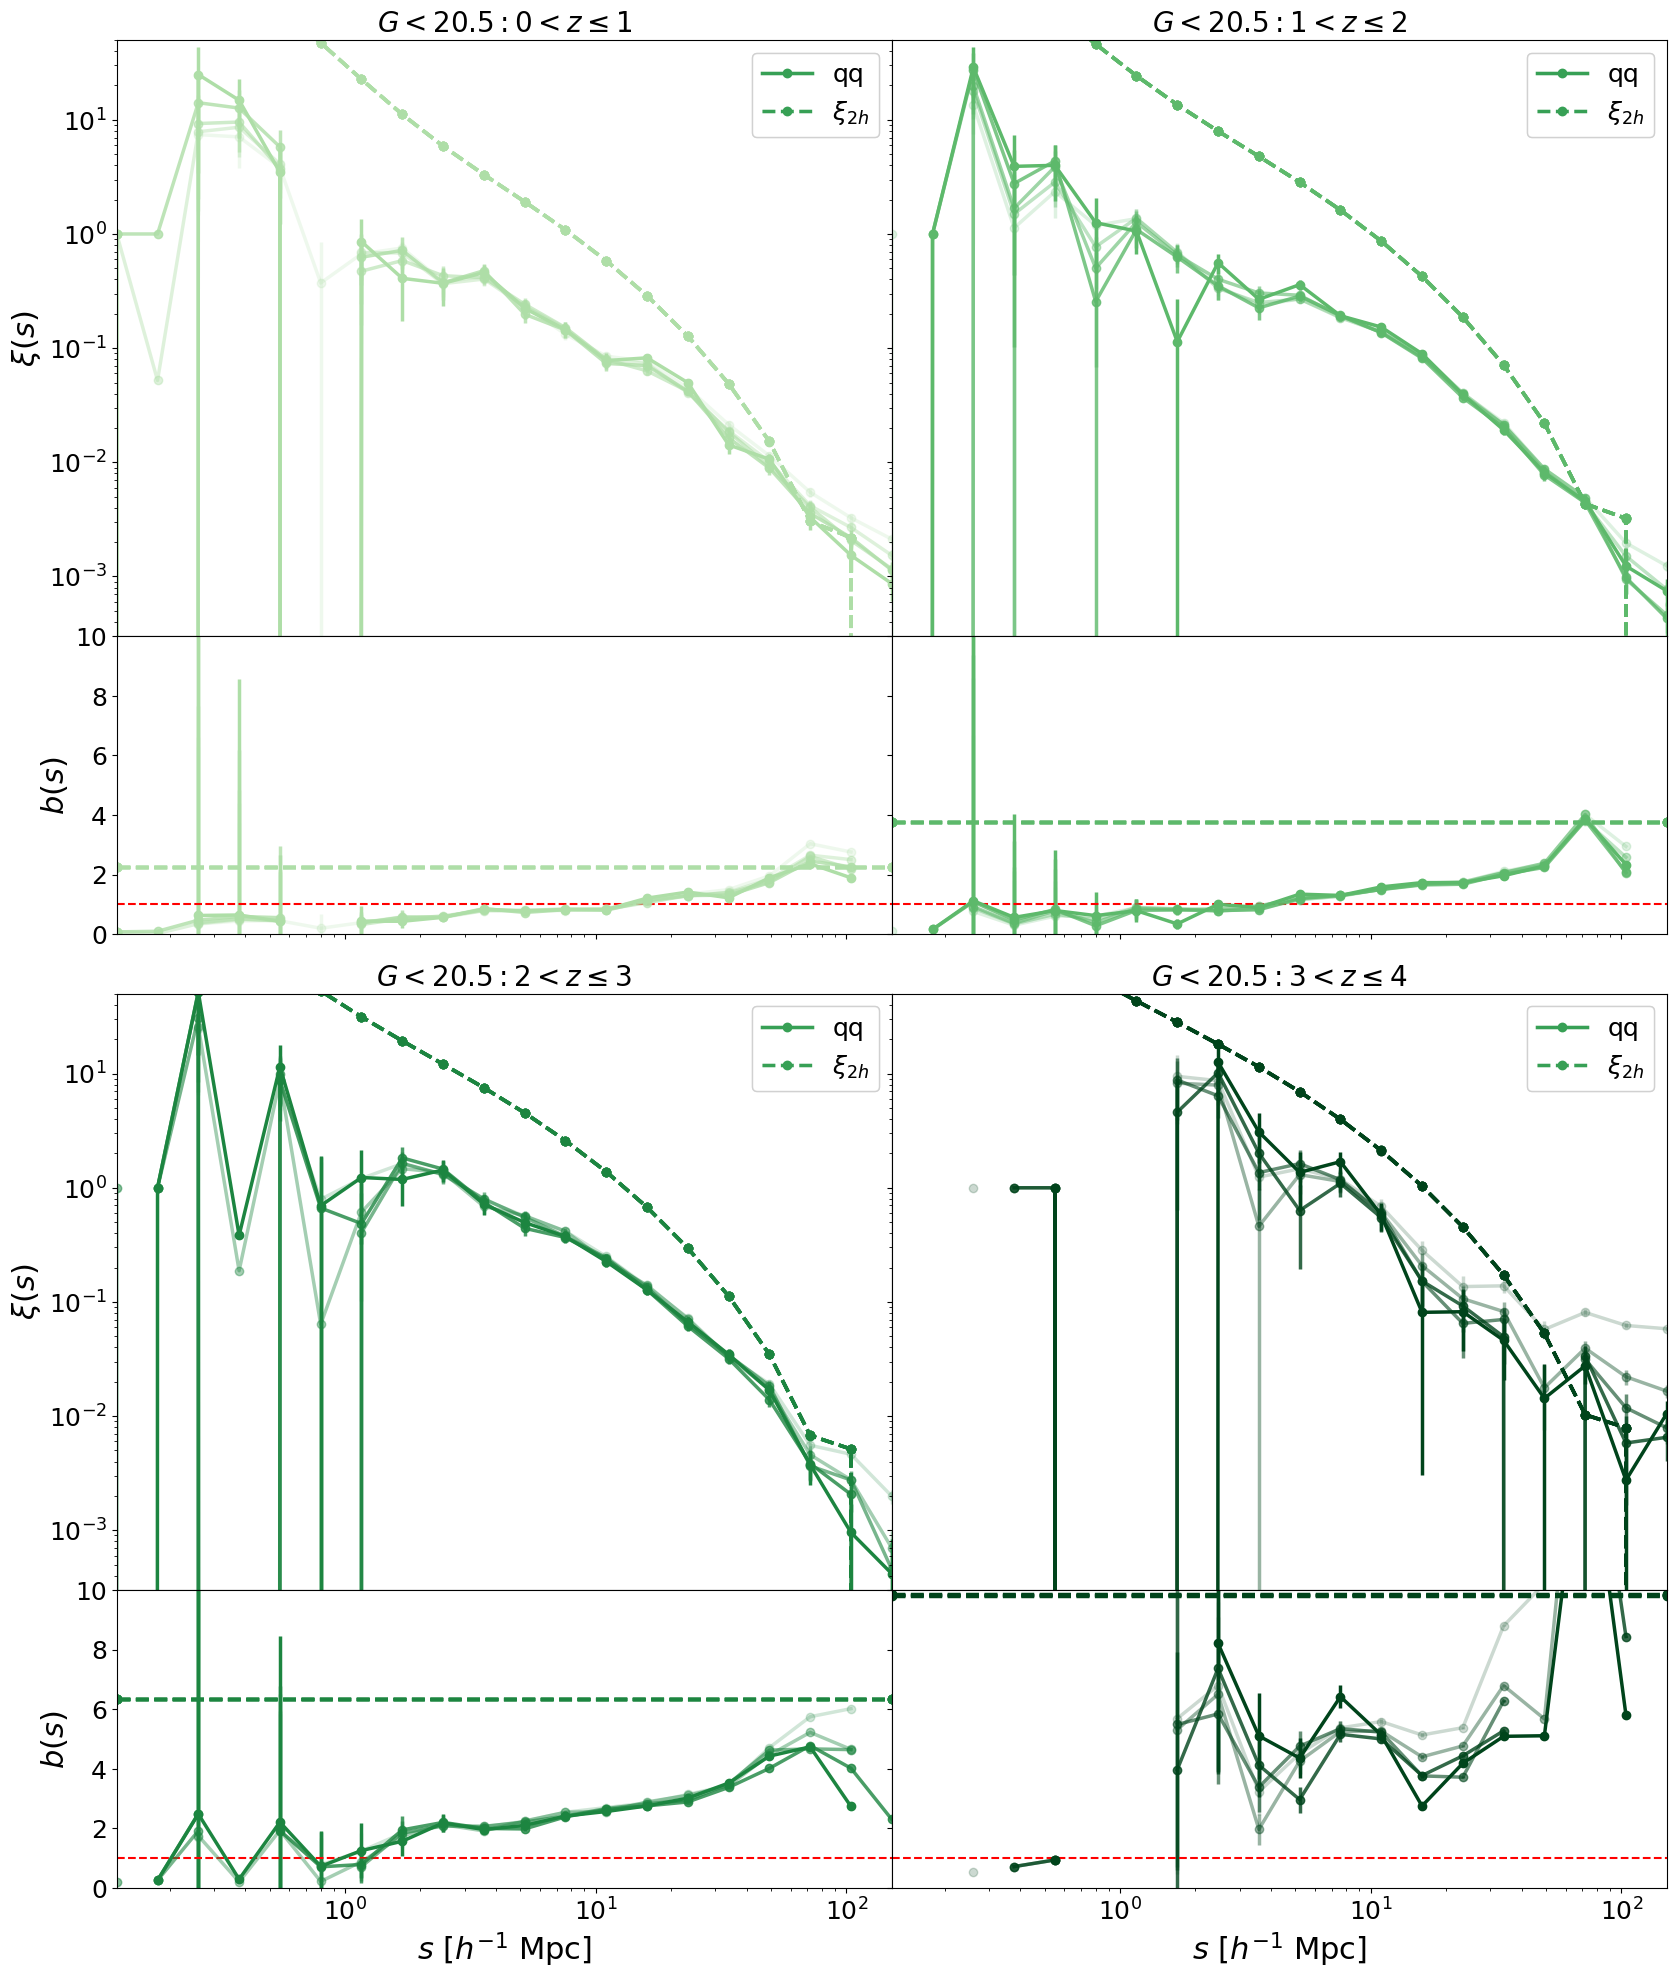

In [35]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

k = 0

for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    for b in [10, 20, 30, 40, 50]:

        cf = np.load('../results/cf_{}_b{}_z{}.npy'.format(labels[i],b,j))
        cf_matter = np.load('../results/cf_matter_{}_b{}_z{}.npy'.format(labels[i],b,j))
        a = np.load('../results/a_{}_b{}_z{}.npy'.format(labels[i],b,j))
        yerr = np.load('../results/yerr_{}_b{}_z{}.npy'.format(labels[i],b,j))
        cf_2h_zbin, b_q = cf_2h(bins, n_m_array[j], float(a), cosmos[i], cf_matter)

        ax1.errorbar(quaia.recenter(rbins), cf, linewidth = 2.5, marker = 'o', label = r'qq', color = cmaps[i][j], yerr = yerr, alpha = b/50)
        ax1.plot(quaia.recenter(rbins), cf_2h_zbin, linewidth = 2.5, marker = 'o', label = r'\xi_2h}', color = cmaps[i][j], linestyle = '--')

        b_eff = np.load('../results/b_eff_{}_b{}_z{}.npy'.format(labels[i],b,j))
        ax2.errorbar(quaia.recenter(rbins), b_eff, linewidth = 2.5, marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), 
                     color = cmaps[i][j], yerr = yerr, alpha = b/50)
        ax2.axhline(b_q, linewidth = 2.5, marker = 'o', color = cmaps[i][j], linestyle = '--')

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(3e-4, 5e1)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$\xi(s)$')
        ax2.set_ylabel(r'$b(s)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

## Calculate derived parameters
### Plot b(z)

In [36]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [37]:
b_cf20 = np.load('../results/b_cf20.npy')
b_wp20 = np.load('../results/b_wp20.npy')

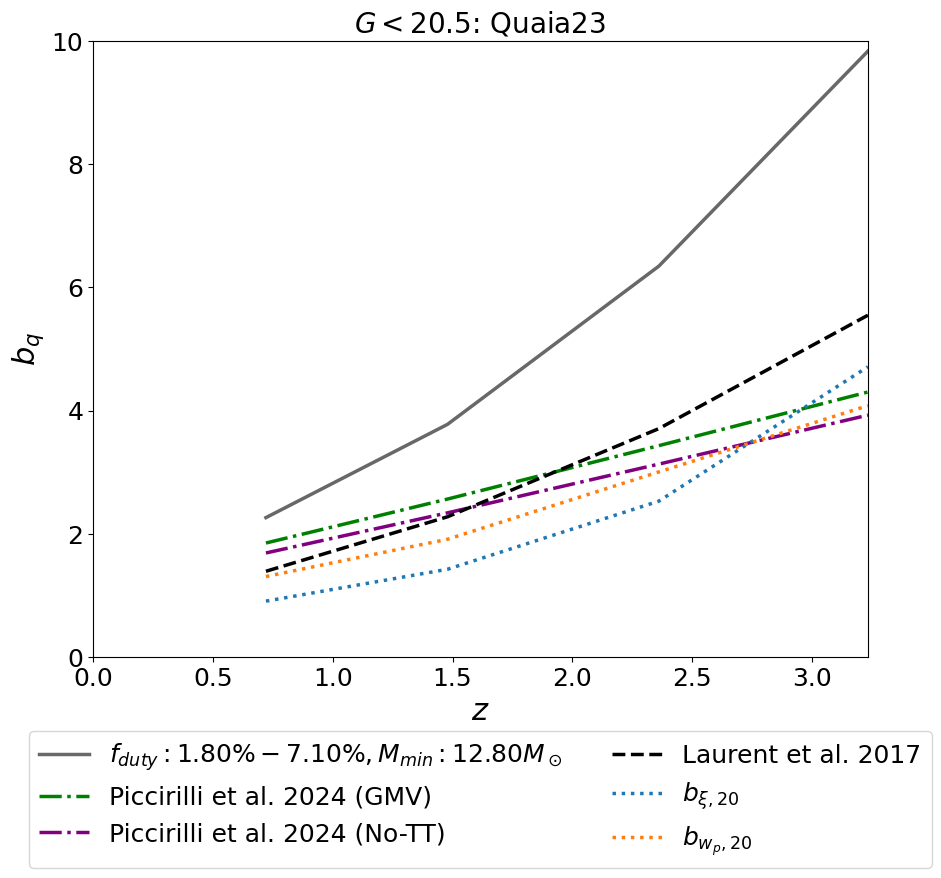

In [38]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']

b_q = [cf_2h(bins, n_m_array[j], a_zbin[labels[i]][j], cosmos[i], cf_matter_zbin_percentile[labels[i]][j])[1] for j in z_array]
zbin = 1/np.array(a_zbin[labels[i]])-1
# for j in z_array:
plt.plot(zbin, b_q, linewidth = 2.5, color = grey,
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, M_min))
plt.plot(zbin, b_quaia(1.26, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
plt.plot(zbin, b_quaia(1.15, a_zbin[labels[i]]), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
plt.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

plt.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$') 
plt.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$') 

plt.title('$G<{}$: {}'.format(G_hi, labels[i]))

# custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
#                 Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
# second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
# ax1.add_artist(second_legend)

plt.xlabel('$z$')
plt.ylim(0, 10)
plt.xlim(0, zbin[-1])
plt.ylabel(r'$b_q$')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')

plt.show()

### Calculate halo mass as $\langle M \rangle \approx n_q^{-1} \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle M$

In [39]:
M_h = [M(bins, n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i])[0] for j in z_array]
# for j in z_array:
#     M_h, n_g = M(bins, n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i])
#     M_h_array.append(M_i)
#     n_g_array.append(n_g)

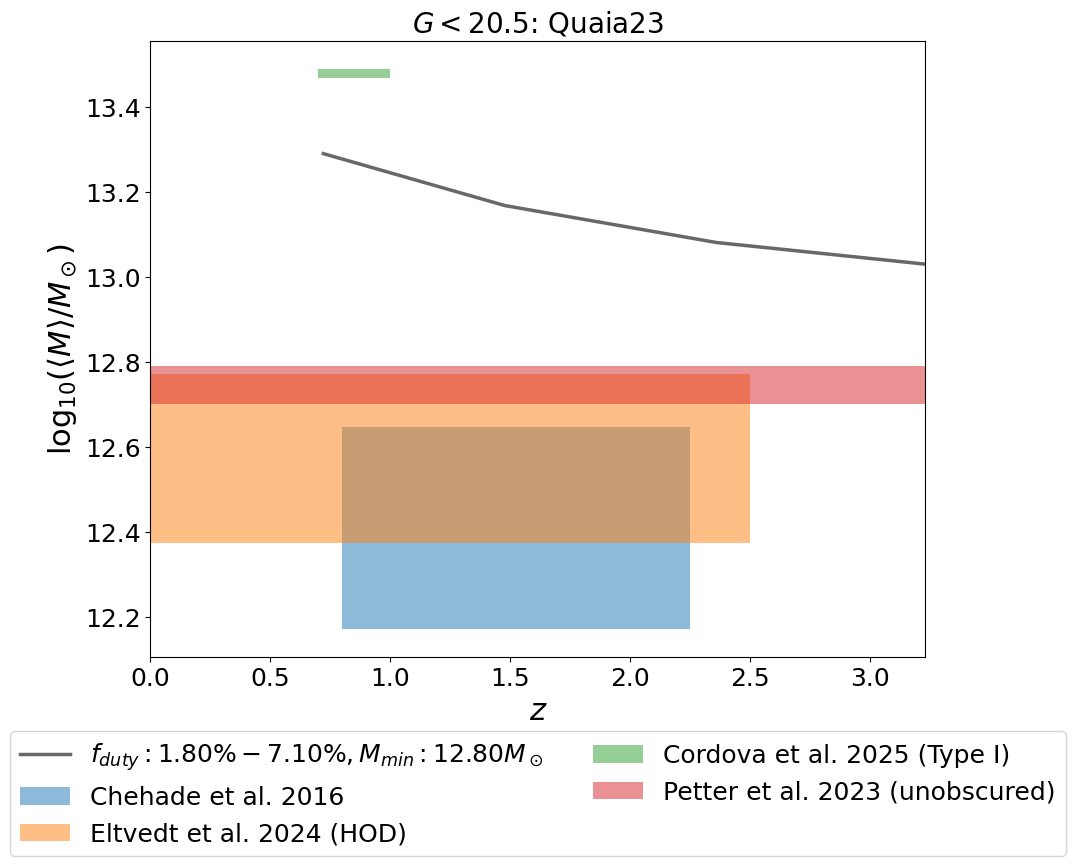

In [40]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
i = 1
# for j in z_array:
plt.plot(zbin, np.log10(M_h), linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, M_min), color = grey)
z = np.linspace(0.8, 2.25)
# plt.plot(z, [np.log10(2e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, label = 'Chehade et al. 2016')
plt.fill_between(z, [np.log10(1e12/cosmo_quaia['h'])]*len(z), [np.log10(3e12/cosmo_quaia['h'])]*len(z), alpha = 0.5, label = 'Chehade et al. 2016')
plt.title('$G<{}$: {}'.format(G_hi, labels[i]))
# plt.plot(np.linspace(0, 2.5), [np.log10(2.5e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, label = 'Eltvedt et al. 2024', color = 'brown')
plt.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/cosmo_quaia['h'])]*len(z), [np.log10(4e12/cosmo_quaia['h'])]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5)
plt.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)')
plt.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/cosmo_quaia['h'])]*len(z), [np.log10(10**12.62/cosmo_quaia['h'])]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)') # check redshift range and check cordova type i was right to include because conflicts with this

custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

plt.xlabel('$z$')
plt.legend(ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
plt.ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
plt.xlim(0, zbin[-1])
plt.show()

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [41]:
n_q_theory = [M(bins, n_m_array[j], a = a_zbin[labels[i]][j], cosmo = cosmos[i])[1] for j in z_array]

In [42]:
r = np.append([0], (quaia.comoving_dist(zbin, h = cosmo_quaia['h'], Om0 = cosmo_quaia['Omega_b']+cosmo_quaia['Omega_c'])).value)

In [55]:
n_q, n_q_err = [], []
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    N = len(tab_datahi_mask_zbin0)
    V = (4/3*np.pi*(r[j+1]**3-r[j]**3))
    n_q.append(N/V)
    # zbin_err.append(stats.median_abs_deviation(tab_datahi_mask_zbin0['redshift_quaia']))
    n_q_err.append(np.sqrt(N)/V) # Poisson error

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336
G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196
G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508
G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


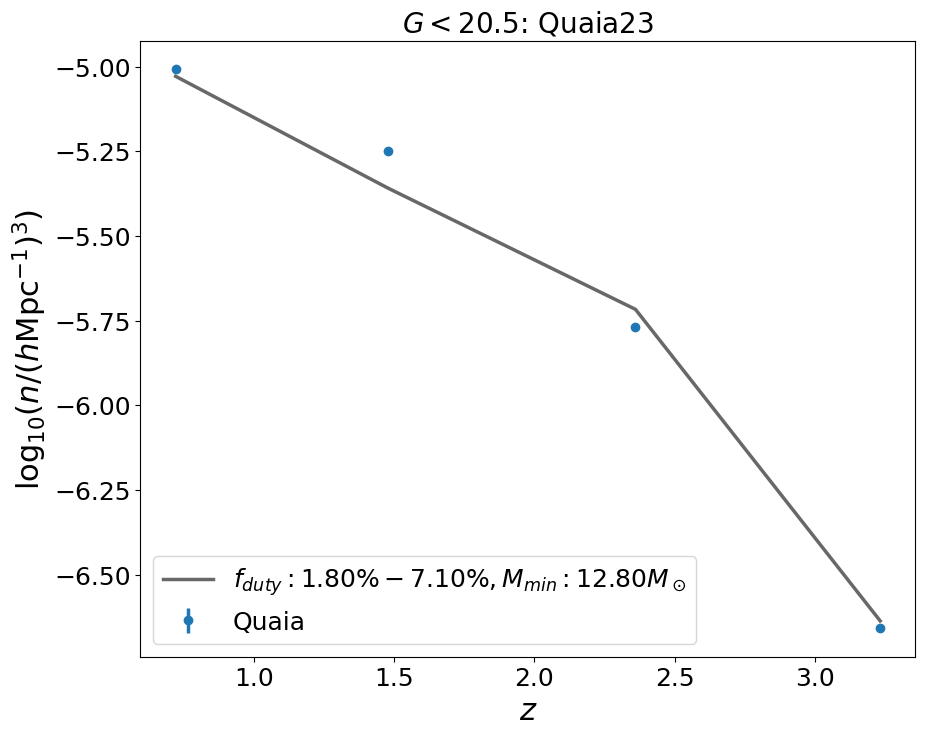

In [72]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']

plt.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, 
         label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, M_min), color = grey)
# plt.scatter(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia')
plt.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

plt.title('$G<{}$: {}'.format(G_hi, labels[i]))

custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
ax1.add_artist(second_legend)

plt.xlabel('$z$')
plt.legend()
plt.ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
plt.show()

In [ ]:
s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)**2, quaia.recenter(pibins)**2), axis = 0))

In [ ]:
Omega_m_array = [Omega_m, Omega_m_quaia]
h_array = [h, h_quaia]
cosmos = [cosmo, cosmo_quaia]
linestyles = ['-', '--']
H0_array = [H0, H0_quaia]

wp_zbin_percentile, wp_matter_zbin_percentile = {label: [] for label in labels}, {label: [] for label in labels}
rpavg_zbin_percentile = {label: [] for label in labels}
yerr_wp, b_wp = {label: [] for label in labels}, {label: [] for label in labels}
for i in range(len(Omega_m_array)):
    
    for j in z_array:
    
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                         bins = [z_bins], tab_gcat_type = 'data',
                                                                                         method = ['minmax'], fac_rand = 25,
                                                                                         n_bins = [None], mask = mask)
        wp_zbin_i, rpavg_zbin_i, qq, qr = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, Om0 = Omega_m_array[i], h = h_array[i],
                                                          nthreads = nthreads, rbins = rpbins, nbins = nbins, pimax = pimax, error = True)
        wp_zbin_percentile[labels[i]].append(wp_zbin_i)
        rpavg_zbin_percentile[labels[i]].append(rpavg_zbin_i)

        # version 3
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0_array[i]))
        
        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmos[i], r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
        wp_matter_zbin_percentile[labels[i]].append(wp_matter_zbin_i)
        
        b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
        yerr=(1+wp_zbin_i)/np.sqrt(qq)
        yerr[wp_zbin_i<0]=np.sqrt((1+b**2*wp_matter_zbin_i)/qr)[wp_zbin_i<0] #https://arxiv.org/abs/1603.04849
        
        yerr_wp[labels[i]].append(yerr)
        b_wp[labels[i]].append(b)

In [ ]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr=yerr_wp[labels[i]][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 12))
gs = gridspec.GridSpec(2, 2, height_ratios = [1, 0.5], hspace = 0, wspace = 0)

# labels = ['Corrfunc', 'Quaia']
labels_cf = ['qq', 'mm']
for i in range(len(Omega_m_array)):
    
    ax1 = fig.add_subplot(gs[i])
    ax2 = fig.add_subplot(gs[i+2])

    for j in z_array:
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])

    ax1.set_title('$G<{}$: {}'.format(G_hi, labels[i]))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)
    
    custom_lines = [Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '-', linewidth = 2.5), 
                    Line2D([0], [0], color = colors[i], marker = 'o', linestyle = '--', linewidth = 2.5)]
    second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
    ax1.add_artist(second_legend)

    ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)
    ax2.legend()
    
    if i == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')
    
    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])
        
    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j],
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)

labels_cf = ['qq', 'mm']

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
        
    for i in range(len(Omega_m_array)):
    
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', 
                     color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmaps[i][j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmaps[i][j], yerr = yerr_wp[labels[i]][j])

    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(4, 25)
    ax1.set_xticklabels([])
    ax1.set_ylim(8e-3, 9e2)

    if j == 0:
        custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                        Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
        second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right')
        ax1.add_artist(second_legend)

    patch = [mpatches.Patch(color=cmaps[l][j], label = labels[l]) for l in range(len(labels))]
    first_legend = ax1.legend(handles=patch, loc = 'lower left')
    ax1.add_artist(first_legend)

    ax2.axhline(1, linestyle = '--', color = 'red')
    ax2.set_xlim(4, 25)
    ax2.set_ylim(0, 5)

    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if scale == 'log':
        ax1.set_xscale('log')
        ax2.set_xscale('log')

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax2.set_xticklabels([])
            
    if j % 2 != 0:
        k+=4

plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(4, 25)
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                       title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(4, 25)
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j], 
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                       title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
labels_cf = ['qq', 'mm']

for i in range(len(Omega_m_array)):
    
    fig = plt.figure(figsize = (20, 24))
    gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.1, 1, 0.5], hspace = 0, wspace = 0)
    
    k = 0
    for j in z_array:
        
        ax1 = fig.add_subplot(gs[j+k])
        ax2 = fig.add_subplot(gs[j+k+2])

        #cf
        ax1.errorbar(quaia.recenter(rbins), cf_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'qq', color = cmap_qq[j], 
                     yerr = yerr_cf[labels[i]][j])
        ax1.plot(quaia.recenter(rbins), cf_matter_zbin_percentile[labels[i]][j], linewidth = 2.5, marker = 'o', label = r'mm', color = cmap_qq[j], 
                 linestyle = '--')

        ax2.errorbar(quaia.recenter(rbins), np.sqrt(cf_zbin_percentile[labels[i]][j]/cf_matter_zbin_percentile[labels[i]][j]), linewidth = 2.5, 
                     marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_qq[j], yerr = yerr_cf[labels[i]][j])
        
        #wp
        ax1.errorbar(rpavg_zbin_percentile[labels[i]][j], wp_zbin_percentile[labels[i]][j]/rpavg_zbin_percentile[labels[i]][j], linewidth = 2.5, 
                     marker = 'o', label = r'qq', color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])
        ax1.plot(quaia.recenter(rpbins), wp_matter_zbin_percentile[labels[i]][j]/quaia.recenter(rpbins), linewidth = 2.5, marker = 'o', label = r'mm',
                 color = cmap_mm[j], linestyle = '--')

        ax2.errorbar(quaia.recenter(rpbins), bias(wp_zbin_percentile[labels[i]][j], wp_matter_zbin_percentile[labels[i]][j],
                                                  ccl.growth_rate(cosmos[i], a_zbin[labels[i]][j])), linewidth = 2.5, marker = 'o', 
                     label = '${:.0f}<z \leq{:.0f}$'.format(j, j+1), color = cmap_mm[j], yerr = yerr_wp[labels[i]][j])

        if (j + k) % 6 < 2:
            ax1.set_title('${:.0f} <z \leq{:.0f}$'.format(j, j+1))
        ax1.set_yscale('log')
        ax1.set_xlim(4, 25)
        ax1.set_xticklabels([])
        ax1.set_ylim(3e-4, 9e2)

        if j == 0:
            custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                            Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
            second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper right', title = '$G<{},$ {}'.format(G_hi, labels[i]), 
                                       title_fontsize = 18, alignment = 'right')
            ax1.add_artist(second_legend)

        patch = [mpatches.Patch(color=cmaps[l][j], label = [r'$\xi(s)$', '$w_p(r_p)/r_p$'][l]) for l in range(len(labels))]
        first_legend = ax1.legend(handles=patch, loc = 'lower left')
        ax1.add_artist(first_legend)

        ax2.axhline(1, linestyle = '--', color = 'red')
        ax2.set_xlim(4, 25)
        ax2.set_ylim(0, 5)

        if (j+k) % 2 == 0:
            ax1.set_ylabel(r'QSO clustering')
            ax2.set_ylabel(r'QSO bias')

        else:
            ax1.set_yticklabels([])
            ax2.set_yticklabels([])

        if scale == 'log':
            ax1.set_xscale('log')
            ax2.set_xscale('log')

        if k != 0:
            ax2.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
        else:
            ax2.set_xticklabels([])

        if j % 2 != 0:
            k+=4

    plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

for i in range(len(labels)):
    
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_cf[labels[i]][j][k] for j in z_array]

    # for j in z_array:
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
             linestyle = '--')

    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

### $w_p(s)$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rpbins)-10))

for i in range(len(labels)):
    
    wp_zbin_percentile_k = np.array([wp_zbin_percentile[labels[i]][j][k] for j in z_array])
    wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_wp[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, wp_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
             linestyle = '--')

    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
             color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_p({:.2f} h^{{-1}}$ Mpc) $[h^{{-1}}$ Mpc]'.format(quaia.recenter(rpbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rpbins)[k]))

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_cf[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
    # wp
    wp_zbin_percentile_k = np.array([wp_zbin_percentile[labels[i]][j][k] for j in z_array])
    wp_matter_zbin_percentile_k = [wp_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_wp[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, wp_zbin_percentile_k/quaia.recenter(rpbins)[k], marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), linestyle = '--', yerr = yerr_k)
    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(wp_zbin_percentile_k/wp_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), linestyle = '--', yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)/r_p$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
ax1.set_title('$s,r_p = {:.2f}[h^{{-1}}$ Mpc]'.format(quaia.recenter(rbins)[k]))

patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi, w_p/r_p$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b$')

plt.show()

### Quasar bias

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
k = np.argmin(np.abs(quaia.recenter(rbins)-10))

for i in range(len(labels)):
    
    cf_zbin_percentile_k = np.array([cf_zbin_percentile[labels[i]][j][k] for j in z_array])
    cf_matter_zbin_percentile_k = [cf_matter_zbin_percentile[labels[i]][j][k] for j in z_array]
    yerr_k = [yerr_cf[labels[i]][j][k] for j in z_array]
    
    ax1.errorbar(1/np.array(a_zbin[labels[i]])-1, cf_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
                 yerr = yerr_k)
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_zbin_percentile_k, marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), 
             linestyle = '--')

    ax2.errorbar(1/np.array(a_zbin[labels[i]])-1, np.sqrt(cf_zbin_percentile_k/cf_matter_zbin_percentile_k), marker = 'o', label = labels[i], 
                 color = np.mean(cmaps[i], axis = 0), yerr = yerr_k)
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

ax2.set_xlabel('$z$')
ax2.set_ylabel(r'$b({:.2f} h^{{-1}}$ Mpc)'.format(quaia.recenter(rbins)[k]))

plt.show()

In [ ]:
labels_cf = ['qq', 'mm']
cf_20={label: [] for label in labels}
cf_matter_20={label: [] for label in labels}
for i in range(len(Omega_m_array)):

    for j in z_array:

        # quasars
        bounds = quaia.recenter(rbins)<20
        integrand = np.copy(cf_zbin_percentile[labels[i]][j])*quaia.recenter(rbins)**2
        integrand[np.isnan(integrand)]=0
        cf_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))
        
        # matter
        integrand = np.copy(cf_matter_zbin_percentile[labels[i]][j])*quaia.recenter(rbins)**2
        integrand[np.isnan(integrand)]=0
        cf_matter_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rbins)[bounds]))

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(cf_20[labels[i]])/cf_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Compute $w_{p,20}=2 / 20^2 \int_0^{20} w_p(r_p) r_p d r_p$

In [ ]:
labels_cf = ['qq', 'mm']
wp_20={label: [] for label in labels}
wp_matter_20={label: [] for label in labels}
for i in range(len(Omega_m_array)):

    for j in z_array:

        # quasars
        bounds = np.array(rpavg_zbin_percentile[labels[i]][j])<20
        integrand = np.copy(wp_zbin_percentile[labels[i]][j])*rpavg_zbin_percentile[labels[i]][j]
        integrand[np.isnan(integrand)]=0
        wp_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], np.array(rpavg_zbin_percentile[labels[i]][j])[bounds]))
        
        # matter
        integrand = np.copy(wp_matter_zbin_percentile[labels[i]][j])*quaia.recenter(rpbins)
        integrand[np.isnan(integrand)]=0
        wp_matter_20[labels[i]].append(3/(20**3)*np.trapz(integrand[bounds], quaia.recenter(rpbins)[bounds]))

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(wp_20[labels[i]])/wp_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(cf_20[labels[i]])/cf_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, np.sqrt(np.array(wp_20[labels[i]])/wp_matter_20[labels[i]]), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{20,qq}}}{\xi^{(r)}_\mathrm{20,mm}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(cf_20[labels[i]]), cf_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], 
    axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

## Calculate $b_{20,\mathrm{qq}}(z)=\sqrt{\frac{w^{(s)}_{p,20,{\mathrm{qq}}}}{w^{(r)}_{p,20\mathrm{mm}}}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_matter_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(wp_20[labels[i]]), wp_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, labels_cf, loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$w_{p,20}$')
# ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 16))
gs = gridspec.GridSpec(2, 1, hspace = 0)
    
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
    
for i in range(len(labels)):
    
    # cf
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, cf_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(cf_20[labels[i]]), cf_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0))
    
    # wp
    ax1.plot(1/np.array(a_zbin[labels[i]])-1, wp_20[labels[i]], marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    ax2.plot(1/np.array(a_zbin[labels[i]])-1, bias(np.array(wp_20[labels[i]]), wp_matter_20[labels[i]], ccl.growth_rate(cosmos[i], a_zbin[labels[i]])-1), marker = 'o', label = labels[i], color = np.mean(cmaps[i], axis = 0), linestyle = '--')
    
custom_lines = [Line2D([0], [0], color = 'black', marker = 'o', linestyle = '-', linewidth = 2.5), 
                Line2D([0], [0], color = 'black', marker = 'o', linestyle = '--', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', '$w_p(r_p)$'], loc = 'upper left', title = '$G<{}$'.format(G_hi), title_fontsize = 18, alignment = 'right')
ax1.add_artist(second_legend)
        
patch = [mpatches.Patch(color=np.mean(cmaps[l], axis = 0), label = labels[l]) for l in range(len(labels))]
first_legend = ax2.legend(handles=patch, loc = 'upper left')
ax2.add_artist(first_legend)
    
ax1.set_xticklabels([])
ax1.set_ylabel(r'$\xi_{20}, w_{p,20}$')

ax2.set_xlabel('$z$')
ax2.set_ylabel('$b_{20}$')

plt.show()